In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D

from Robust_MOSP import Robust_MOSP
from utils.generate_graph import generate_graph

# incrementing node sizes twice the previous
NODE_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
EDGE_PROBS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # edge probablity for nodes
REPEAT = 10  # repetation of 10

results = []
total_runs = len(NODE_SIZES) * len(EDGE_PROBS) * \
    REPEAT  # total number of running time

with tqdm(total=total_runs) as pbar:
    for n in NODE_SIZES:
        for p in EDGE_PROBS:
            for r in range(REPEAT):
                G = generate_graph(n, p)
                start = time.perf_counter()
                Robust_MOSP(G)  # running robust_mosp_update algo
                end = time.perf_counter()
                runtime = end - start  # runtime for running algo

                results.append({
                    "nodes": n,
                    "edge_prob": p,
                    "runtime": runtime
                })

                pbar.update(1)


100%|██████████| 540/540 [31:52<00:00,  3.54s/it] 


In [2]:
# DON'T RUN THIS AGAIN
df = pd.DataFrame(results)
df.to_csv("Robust_MOSP_results.csv", index=False)

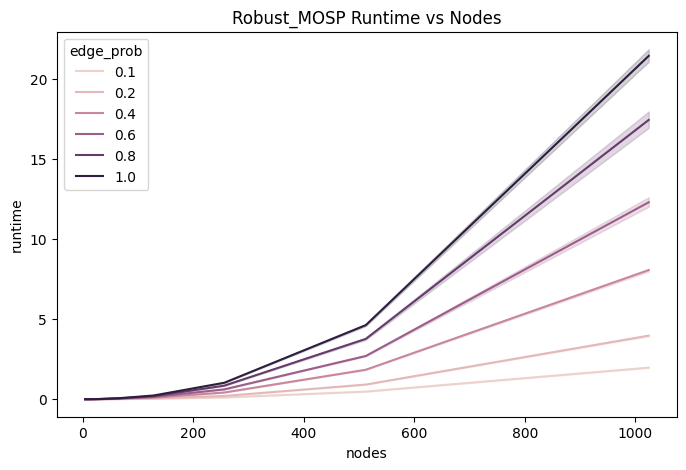

In [3]:
# plotting runtime vs nodes
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="nodes",
    y="runtime",
    hue="edge_prob",
    estimator="mean"
)

plt.title("Robust_MOSP Runtime vs Nodes")
plt.show()

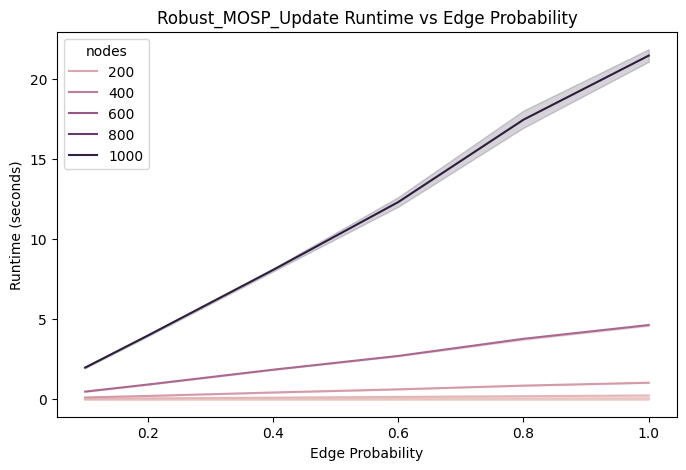

In [4]:
# Runtime vs Edge probablity
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="edge_prob",
             y="runtime",
             hue="nodes",
             estimator="mean")

plt.title("Robust_MOSP_Update Runtime vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")

plt.show()


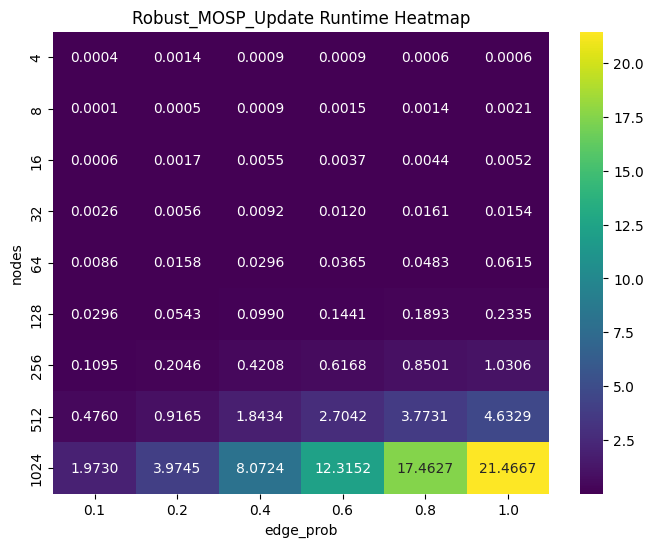

In [5]:
# nodes vs edge probablity
pivot = df.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.title("Robust_MOSP_Update Runtime Heatmap")
plt.show()


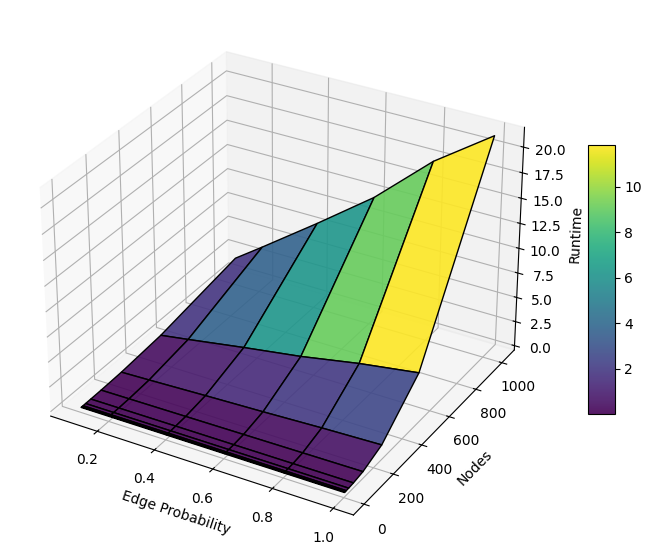

In [6]:
# 3D surface plot
from mpl_toolkits.mplot3d import Axes3D

nodes = pivot.index.values
edge_probs = pivot.columns.values

X, Y = np.meshgrid(edge_probs, nodes)
Z = pivot.values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='k',
    alpha=0.9
)


ax.set_xlabel("Edge Probability")
ax.set_ylabel("Nodes")
ax.set_zlabel("Runtime")
fig.colorbar(surface, shrink=0.5, aspect=10)

plt.show()